In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\rafae\Codigo\federated_learning\flower-tutorial\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Modelo CNN para imágenes médicas
# Definición de la arquitectura de la red
class MedicalCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3, weight_decay=1e-4):
        super(MedicalCNN, self).__init__()
        
        self.weight_decay = weight_decay
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),  # Añadido Dropout2d después de la primera capa
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),  # Añadido Dropout2d después de la segunda capa
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_rate)  # Incrementado el dropout
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512),
            nn.BatchNorm1d(512),  # Añadido BatchNorm
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),  # Capa adicional con menos neuronas
            nn.BatchNorm1d(256),  # Añadido BatchNorm
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
    def get_l2_regularization_loss(self):
        """Calcula la pérdida de regularización L2 para los parámetros del modelo"""
        l2_loss = 0.0
        for param in self.parameters():
            l2_loss += torch.sum(param ** 2)
        return self.weight_decay * l2_loss

In [3]:
# Crear una clase para adaptar el dataset de HuggingFace a PyTorch
class IMGDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image']
        label = item['label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [4]:
# Configuración de transformaciones
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Conversión a escala de grises
    transforms.Resize((224, 224)),                # Redimensionar a 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


In [5]:
# Función de entrenamiento
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Añadir regularización L2
            l2_loss = model.get_l2_regularization_loss()
            total_loss = loss + l2_loss

            total_loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100. * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        
        # Validación
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\n')
    
    # Visualización de resultados
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


In [6]:
# Cargar dataset y aplicar transformaciones
dataset = load_dataset('Augusto777/OCT2017')

# Número de clases en el dataset   
num_classes = len(set(dataset['train']['label']))  

# Verificar si el dataset ya viene con splits predefinidos
if 'train' in dataset and 'validation' in dataset:
    # Usar los splits predefinidos
    train_dataset = IMGDataset(dataset['train'], transform=transform)
    val_dataset = IMGDataset(dataset['validation'], transform=transform)
else:
    # Si solo hay un split o ninguno está definido como 'validation'
    # Dividir manualmente el dataset (asumiendo que 'train' existe)
    from torch.utils.data import random_split
    
    full_dataset = IMGDataset(dataset['train'], transform=transform)
    
    # Definir tamaños para train y validation (80% - 20%)
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Crear los DataLoaders
batch_size = 32  # Ajusta según tus necesidades y recursos

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
    #,num_workers=4
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False
    #,num_workers=4
) 

# Función de preprocesamiento para extraer imagen y etiqueta
def preprocess(batch):
    images = [transform(img) for img in batch['image']]  # Aplica las transformaciones a cada imagen
    labels = batch['label']                              # Toma las etiquetas
    return torch.stack(images), torch.tensor(labels)



Epoch 1/30:
Train Loss: 1.4154, Train Acc: 34.38%
Val Loss: 1.3422, Val Acc: 25.00%

Epoch 2/30:
Train Loss: 1.2482, Train Acc: 42.71%
Val Loss: 1.2889, Val Acc: 30.21%

Epoch 3/30:
Train Loss: 1.1824, Train Acc: 46.35%
Val Loss: 1.1534, Val Acc: 53.12%

Epoch 4/30:
Train Loss: 1.0702, Train Acc: 52.08%
Val Loss: 1.0191, Val Acc: 59.38%

Epoch 5/30:
Train Loss: 1.0175, Train Acc: 55.73%
Val Loss: 0.8277, Val Acc: 64.58%

Epoch 6/30:
Train Loss: 0.8771, Train Acc: 65.89%
Val Loss: 0.7608, Val Acc: 71.88%

Epoch 7/30:
Train Loss: 0.7943, Train Acc: 69.53%
Val Loss: 0.6654, Val Acc: 82.29%

Epoch 8/30:
Train Loss: 0.6857, Train Acc: 74.74%
Val Loss: 0.5493, Val Acc: 82.29%

Epoch 9/30:
Train Loss: 0.6704, Train Acc: 74.74%
Val Loss: 0.4680, Val Acc: 87.50%

Epoch 10/30:
Train Loss: 0.5516, Train Acc: 78.91%
Val Loss: 0.4294, Val Acc: 88.54%

Epoch 11/30:
Train Loss: 0.4760, Train Acc: 84.90%
Val Loss: 0.4453, Val Acc: 89.58%

Epoch 12/30:
Train Loss: 0.4249, Train Acc: 87.76%
Val Loss: 0.

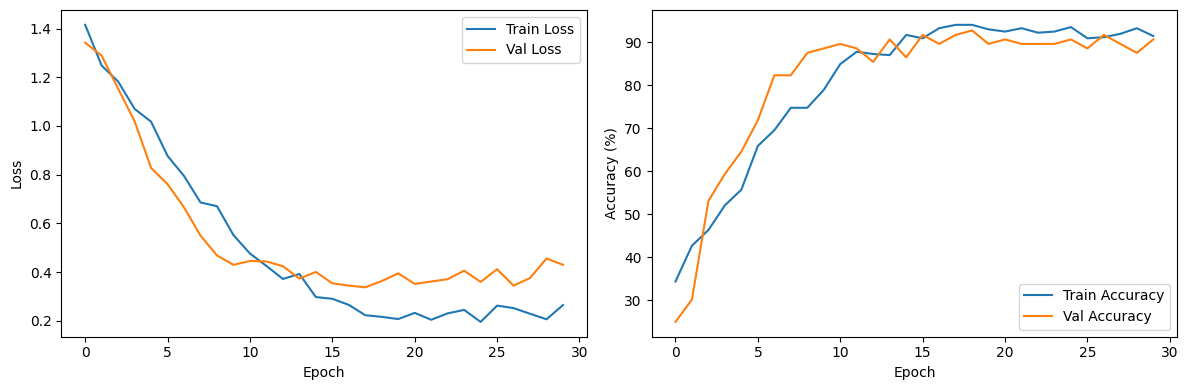

In [7]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.6, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 1.4145, Train Acc: 34.38%
Val Loss: 1.3525, Val Acc: 26.04%

Epoch 2/30:
Train Loss: 1.2251, Train Acc: 42.71%
Val Loss: 1.2414, Val Acc: 42.71%

Epoch 3/30:
Train Loss: 1.0881, Train Acc: 52.60%
Val Loss: 1.1326, Val Acc: 56.25%

Epoch 4/30:
Train Loss: 0.9817, Train Acc: 59.11%
Val Loss: 0.9255, Val Acc: 70.83%

Epoch 5/30:
Train Loss: 0.8312, Train Acc: 67.19%
Val Loss: 0.7778, Val Acc: 73.96%

Epoch 6/30:
Train Loss: 0.7464, Train Acc: 74.48%
Val Loss: 0.6208, Val Acc: 81.25%

Epoch 7/30:
Train Loss: 0.6704, Train Acc: 74.48%
Val Loss: 0.5183, Val Acc: 82.29%

Epoch 8/30:
Train Loss: 0.5756, Train Acc: 81.25%
Val Loss: 0.5186, Val Acc: 83.33%

Epoch 9/30:
Train Loss: 0.4660, Train Acc: 84.11%
Val Loss: 0.4141, Val Acc: 86.46%

Epoch 10/30:
Train Loss: 0.4010, Train Acc: 86.98%
Val Loss: 0.3574, Val Acc: 91.67%

Epoch 11/30:
Train Loss: 0.3785, Train Acc: 87.24%
Val Loss: 0.3177, Val Acc: 93.75%

Epoch 12/30:
Train Loss: 0.3110, Train Acc: 89.58%
Val Loss: 0.

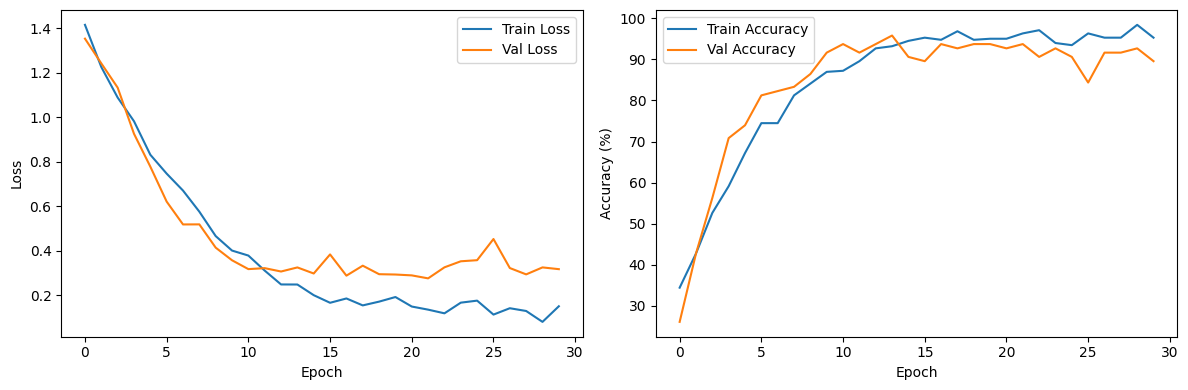

In [8]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.4, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 1.4282, Train Acc: 31.25%
Val Loss: 1.3227, Val Acc: 37.50%

Epoch 2/30:
Train Loss: 1.2668, Train Acc: 41.41%
Val Loss: 1.1983, Val Acc: 48.96%

Epoch 3/30:
Train Loss: 1.2439, Train Acc: 44.27%
Val Loss: 1.1159, Val Acc: 53.12%

Epoch 4/30:
Train Loss: 1.1342, Train Acc: 50.26%
Val Loss: 1.0130, Val Acc: 63.54%

Epoch 5/30:
Train Loss: 1.0371, Train Acc: 55.99%
Val Loss: 0.8567, Val Acc: 68.75%

Epoch 6/30:
Train Loss: 0.9249, Train Acc: 60.68%
Val Loss: 0.7415, Val Acc: 71.88%

Epoch 7/30:
Train Loss: 0.8481, Train Acc: 65.89%
Val Loss: 0.6667, Val Acc: 77.08%

Epoch 8/30:
Train Loss: 0.7643, Train Acc: 71.09%
Val Loss: 0.5753, Val Acc: 81.25%

Epoch 9/30:
Train Loss: 0.6736, Train Acc: 75.78%
Val Loss: 0.5521, Val Acc: 83.33%

Epoch 10/30:
Train Loss: 0.5913, Train Acc: 78.12%
Val Loss: 0.4842, Val Acc: 87.50%

Epoch 11/30:
Train Loss: 0.5497, Train Acc: 79.95%
Val Loss: 0.4352, Val Acc: 88.54%

Epoch 12/30:
Train Loss: 0.4652, Train Acc: 84.38%
Val Loss: 0.

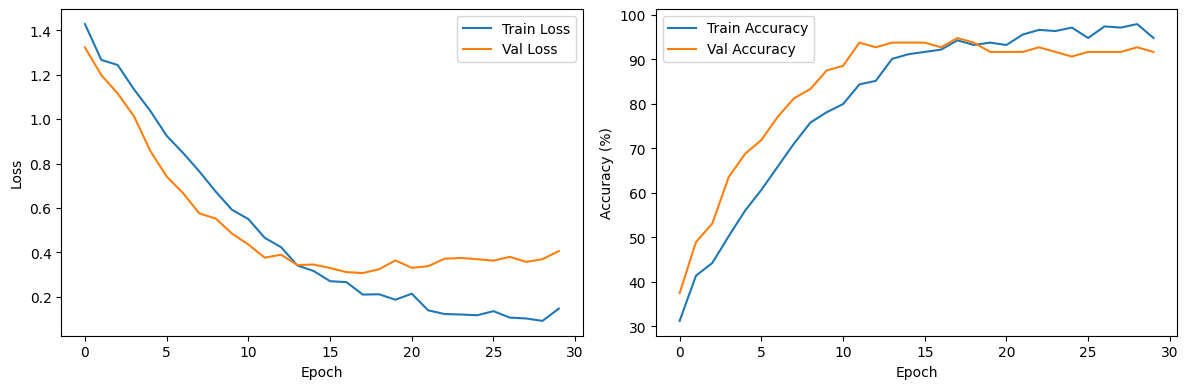

In [9]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.6, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 1.3832, Train Acc: 37.24%
Val Loss: 1.3611, Val Acc: 22.92%

Epoch 2/30:
Train Loss: 1.1631, Train Acc: 50.78%
Val Loss: 1.2029, Val Acc: 41.67%

Epoch 3/30:
Train Loss: 1.1538, Train Acc: 53.12%
Val Loss: 1.0261, Val Acc: 62.50%

Epoch 4/30:
Train Loss: 1.0155, Train Acc: 59.64%
Val Loss: 0.8883, Val Acc: 75.00%

Epoch 5/30:
Train Loss: 0.9040, Train Acc: 65.36%
Val Loss: 0.7496, Val Acc: 79.17%

Epoch 6/30:
Train Loss: 0.7628, Train Acc: 70.31%
Val Loss: 0.5963, Val Acc: 83.33%

Epoch 7/30:
Train Loss: 0.6770, Train Acc: 76.30%
Val Loss: 0.5167, Val Acc: 80.21%

Epoch 8/30:
Train Loss: 0.5745, Train Acc: 79.43%
Val Loss: 0.4754, Val Acc: 89.58%

Epoch 9/30:
Train Loss: 0.4601, Train Acc: 83.07%
Val Loss: 0.4062, Val Acc: 90.62%

Epoch 10/30:
Train Loss: 0.4148, Train Acc: 86.98%
Val Loss: 0.3879, Val Acc: 85.42%

Epoch 11/30:
Train Loss: 0.3111, Train Acc: 90.10%
Val Loss: 0.3675, Val Acc: 86.46%

Epoch 12/30:
Train Loss: 0.2856, Train Acc: 91.67%
Val Loss: 0.

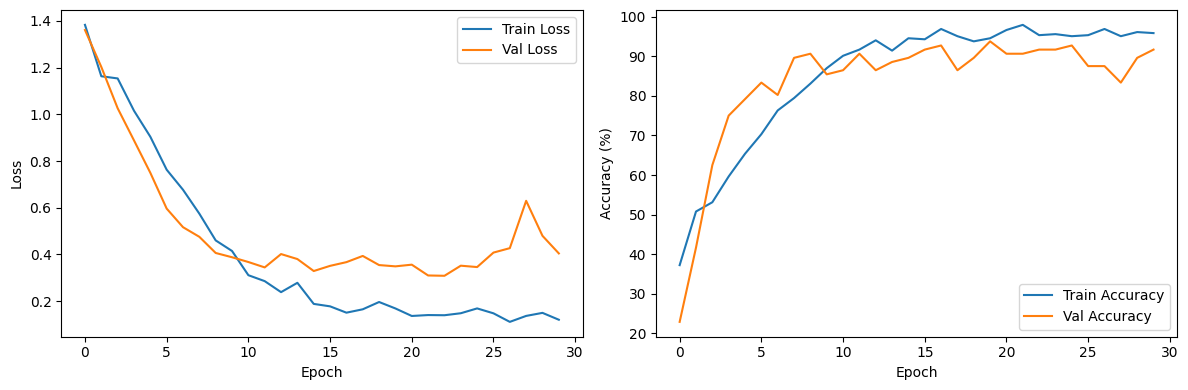

In [10]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.4, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 1.4844, Train Acc: 26.04%
Val Loss: 1.3942, Val Acc: 22.92%

Epoch 2/30:
Train Loss: 1.4055, Train Acc: 34.38%
Val Loss: 1.3450, Val Acc: 31.25%

Epoch 3/30:
Train Loss: 1.3515, Train Acc: 39.58%
Val Loss: 1.2495, Val Acc: 44.79%

Epoch 4/30:
Train Loss: 1.2718, Train Acc: 42.71%
Val Loss: 1.1512, Val Acc: 55.21%

Epoch 5/30:
Train Loss: 1.2424, Train Acc: 46.09%
Val Loss: 1.0896, Val Acc: 53.12%

Epoch 6/30:
Train Loss: 1.2025, Train Acc: 46.88%
Val Loss: 1.0227, Val Acc: 58.33%

Epoch 7/30:
Train Loss: 1.1692, Train Acc: 50.26%
Val Loss: 0.9729, Val Acc: 58.33%

Epoch 8/30:
Train Loss: 1.0859, Train Acc: 54.43%
Val Loss: 0.9025, Val Acc: 62.50%

Epoch 9/30:
Train Loss: 1.0171, Train Acc: 56.25%
Val Loss: 0.8768, Val Acc: 62.50%

Epoch 10/30:
Train Loss: 0.9886, Train Acc: 59.11%
Val Loss: 0.8093, Val Acc: 69.79%

Epoch 11/30:
Train Loss: 0.8995, Train Acc: 63.28%
Val Loss: 0.7483, Val Acc: 71.88%

Epoch 12/30:
Train Loss: 0.8482, Train Acc: 65.62%
Val Loss: 0.

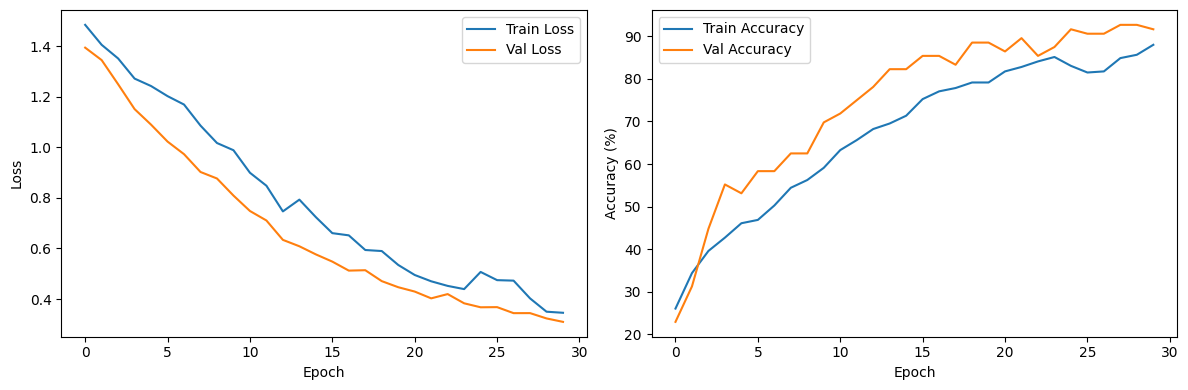

In [11]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.8, weight_decay=1e-3)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)

Epoch 1/30:
Train Loss: 1.4552, Train Acc: 29.69%
Val Loss: 1.3895, Val Acc: 22.92%

Epoch 2/30:
Train Loss: 1.4211, Train Acc: 35.42%
Val Loss: 1.2888, Val Acc: 45.83%

Epoch 3/30:
Train Loss: 1.3724, Train Acc: 37.76%
Val Loss: 1.2476, Val Acc: 40.62%

Epoch 4/30:
Train Loss: 1.2907, Train Acc: 41.67%
Val Loss: 1.1818, Val Acc: 58.33%

Epoch 5/30:
Train Loss: 1.2417, Train Acc: 44.01%
Val Loss: 1.1119, Val Acc: 57.29%

Epoch 6/30:
Train Loss: 1.1849, Train Acc: 46.61%
Val Loss: 1.0502, Val Acc: 62.50%

Epoch 7/30:
Train Loss: 1.1417, Train Acc: 51.04%
Val Loss: 0.9931, Val Acc: 60.42%

Epoch 8/30:
Train Loss: 1.1497, Train Acc: 49.74%
Val Loss: 0.9313, Val Acc: 59.38%

Epoch 9/30:
Train Loss: 1.0650, Train Acc: 56.51%
Val Loss: 0.8969, Val Acc: 64.58%

Epoch 10/30:
Train Loss: 1.0008, Train Acc: 60.68%
Val Loss: 0.8376, Val Acc: 67.71%

Epoch 11/30:
Train Loss: 0.9547, Train Acc: 58.85%
Val Loss: 0.7996, Val Acc: 66.67%

Epoch 12/30:
Train Loss: 0.8711, Train Acc: 64.06%
Val Loss: 0.

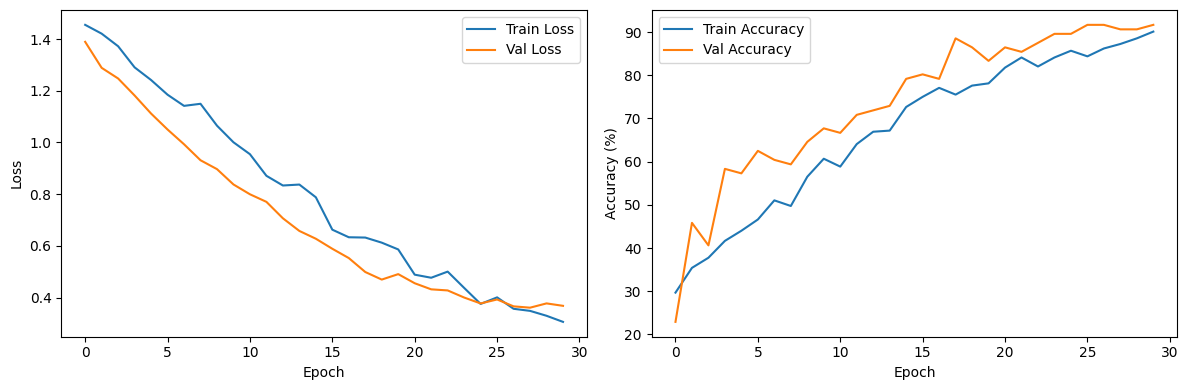

In [12]:
# limpiar caché de CUDA si está disponible
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Inicializar modelo y criterios
model = MedicalCNN(num_classes=num_classes, dropout_rate=0.8, weight_decay=1e-4)  
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Entrenar modelo
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30)